In [1]:
import pandas as pd
import geopandas as gpd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cmocean
import gsw

# Loading and formating data

In [2]:
ctd_all = pd.read_csv('/Users/Sam/Documents/Postdoc/Cruise/Processed CTD Data/at5036_013_nav_3sigFilter.csv')
bathy_all = xr.open_dataset('/Users/Sam/Documents/Postdoc/Cruise/Cruise Data/sentry_epr_1m.nc')

In [3]:
ctd_all['abs_sal'] = gsw.SA_from_SP(SP=ctd_all['salinity'],p=ctd_all['pressure'],
                                    lat=ctd_all['Latitude'],lon=ctd_all['Longitude'])

In [4]:
ctd_bottom = ctd_all.loc[ctd_all['depth'] >= 2485]
ctd_bottom_geo = gpd.GeoDataFrame(ctd_bottom,geometry=gpd.points_from_xy(ctd_bottom.USBL_lon,ctd_bottom.USBL_lat),crs="EPSG:4326")

lon_min, lat_min, lon_max, lat_max = ctd_bottom_geo.total_bounds

lon_buffer = (lon_max - lon_min) * 0.07
lat_buffer = (lat_max - lat_min) * 0.07

plot_lon_min = lon_min - lon_buffer
plot_lon_max = lon_max + lon_buffer
plot_lat_min = lat_min - lat_buffer
plot_lat_max = lat_max + lat_buffer

bathy_crop = bathy_all.sel(lat=slice(plot_lat_min,plot_lat_max),lon=slice(plot_lon_min,plot_lon_max))

In [5]:
avg_latitude = (lat_min + lat_max) / 2
lon_range = (lon_max - lon_min) * np.cos(np.radians(avg_latitude))
lat_range = lat_max - lat_min

aspect_ratio = lon_range / lat_range if lat_range != 0 else 1

base_size = 10
if aspect_ratio > 1:
    figsize_temp = (base_size, base_size / aspect_ratio)
else:
    figsize_temp = (base_size * aspect_ratio, base_size)

figsize = (max(figsize_temp[0], 6), max(figsize_temp[1], 6))

# Temperature plots

In [6]:
ctd_sorted = ctd_bottom.sort_values('pottemp')

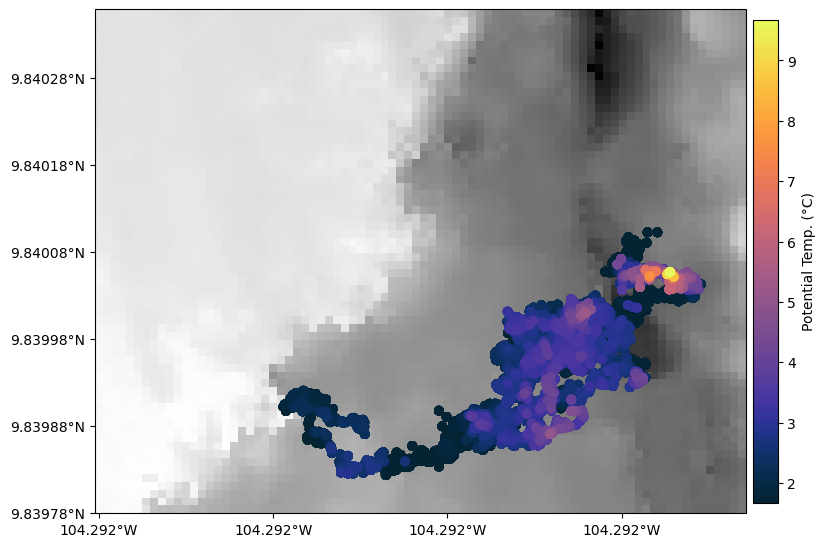

In [7]:
ctd_sorted = ctd_bottom.loc[ctd_bottom['pottemp'] > 0].sort_values('pottemp')
prj=ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=figsize,subplot_kw={'projection': prj})
bathy_crop['Band1'].plot(ax=ax,cmap='gray',rasterized=True,add_colorbar=False)
temp = ax.scatter(ctd_sorted['Longitude'], ctd_sorted['Latitude'], 
                  c=ctd_sorted['pottemp'], cmap='cmo.thermal',
                  )

x_ticks = list(np.arange(np.round(float(bathy_crop.lon.min()),5), np.round(float(bathy_crop.lon.max()),5)+0.00001, .0002))
y_ticks = list(np.arange(np.round(float(bathy_crop.lat.min()),5), np.round(float(bathy_crop.lat.max()),5)+0.00001, .0001))
ax.set_xticks(x_ticks, crs=prj)
ax.set_yticks(y_ticks, crs=prj)
ax.xaxis.set_major_formatter(LongitudeFormatter())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.set_xlabel('')
ax.set_ylabel('')

fig.colorbar(temp, ax=ax, pad=0.01, shrink=0.8).set_label('Potential Temp. (°C)')

fig.savefig('CTD13_Ptemp.pdf',dpi=300)

# Salinity Plots

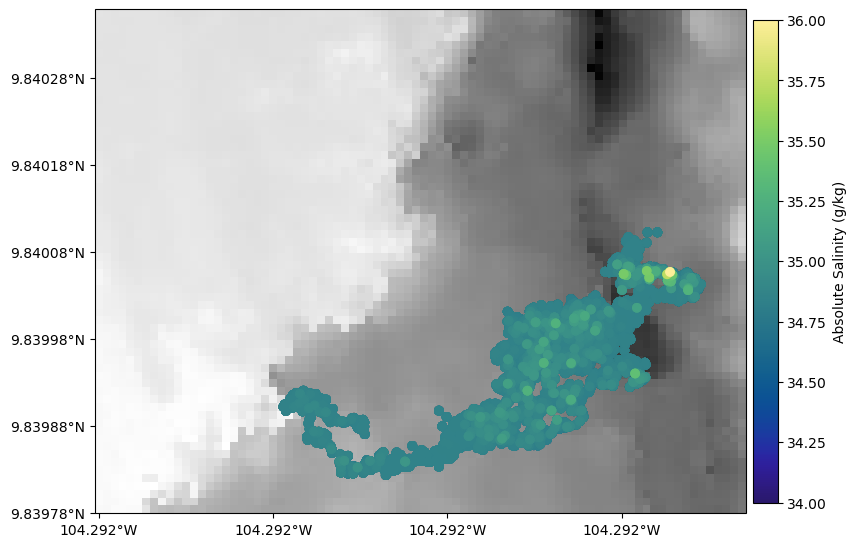

In [8]:
ctd_sorted = ctd_bottom.loc[ctd_bottom['salinity']<40].sort_values('salinity')

prj=ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=figsize,subplot_kw={'projection': prj})
bathy_crop['Band1'].plot(ax=ax,cmap='gray',rasterized=True,add_colorbar=False)
temp = ax.scatter(ctd_sorted['Longitude'], ctd_sorted['Latitude'], 
                  c=ctd_sorted['abs_sal'], cmap='cmo.haline',
                 vmin=34,vmax=ctd_sorted['salinity'].max().round(0))

x_ticks = list(np.arange(np.round(float(bathy_crop.lon.min()),5), np.round(float(bathy_crop.lon.max()),5)+0.00001, .0002))
y_ticks = list(np.arange(np.round(float(bathy_crop.lat.min()),5), np.round(float(bathy_crop.lat.max()),5)+0.00001, .0001))
ax.set_xticks(x_ticks, crs=prj)
ax.set_yticks(y_ticks, crs=prj)
ax.xaxis.set_major_formatter(LongitudeFormatter())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.set_xlabel('')
ax.set_ylabel('')

fig.colorbar(temp, ax=ax, pad=0.01, shrink=0.8).set_label('Absolute Salinity (g/kg)')

fig.savefig('CTD13_abs_sal.pdf',dpi=300)

# Correlation

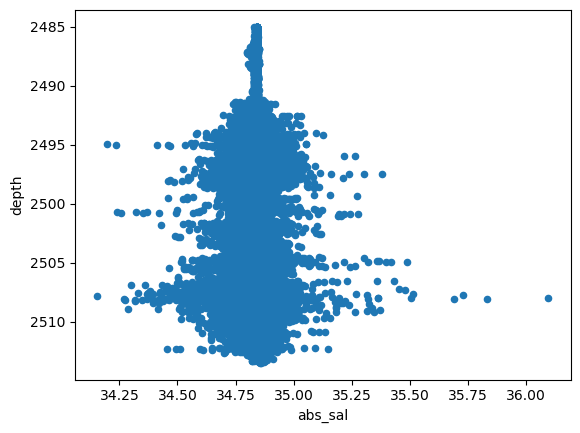

In [9]:
ctd_bottom_cor = ctd_bottom.loc[(ctd_bottom['pottemp'] > 0) & ((ctd_bottom['salinity'] < 40) & (ctd_bottom['salinity'] > 5))]

ctd_bottom_cor.plot(y='depth', x='abs_sal',kind='scatter')
plt.gca().invert_yaxis()